In [3]:
import sys
import os
import json
import numpy as np
import torch
import anndata as ad
from importlib import reload
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score
import pyro 
import umap.umap_ as umap
import matplotlib.patches as mpatches
from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import scipy.sparse
from scipy.sparse import coo_matrix

In [4]:
# Import custom modules
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
reload(sim)

import simulate_pipeline_wALBF as spw
reload(spw)

sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/")
import vis as vis

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/')
import cost_correlation_assign
import differential_splicing
import masking_BBFactor as mask 
import scipy.sparse as sp 

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
float_type = {"device": device, "dtype": torch.float}
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

2.3.0+cu121
12.1
2.3.0+cu121
12.1
2.3.0+cu121
12.1
2.3.0+cu121
12.1
Using device: cuda
Using device: cuda
2.3.0+cu121
12.1
Using device: cuda
Using device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:747: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:431.)
  _C._set_default_tensor_type(t)


In [5]:
input_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSE_Anndata_Object_with_initializations_brain_only_20241018_134852.h5ad"
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/tabula_senis_test_intron_clusters_50_500000_10_20240927_single_cell.gz"

In [6]:
K=2 
proportion_negative=0.5
intron_clusts = pd.read_csv(ATSE_file, sep="}")
genes = intron_clusts[["gene_id", "gene_name"]].drop_duplicates()

In [7]:
adata = spw.load_adata(input_file)
adata.var = pd.merge(adata.var, genes[['gene_id', 'gene_name']], how='left', on='gene_id')
cell_type_column=None 

adata_filtered = spw.preprocess_adata(adata, cell_type_column, "cell_by_cluster_matrix")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [8]:
full_y_tensor, full_total_counts_tensor, adata_input = spw.simulate_and_prepare(adata_filtered, K, float_type, proportion_negative, cell_type_column)

Cluster_Counts nnz: 17001075
Junction_Counts nnz: 9021097
The number of unique junctions included in the simulation data is: 16506
The number of unique clusters included in the simulation data is: 5502


100%|██████████| 5502/5502 [00:03<00:00, 1511.83it/s]
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Cluster_Counts nnz: 16911843
Junction_Counts nnz: 8955930
The proportion of negative ASEs to set is: 0.5
The number of cell types is: 2
The number of cells is: 19942
The number of junctions is: 15894
Number of negative labels (0): 2649
Number of positive labels (1): 2649


100%|██████████| 5298/5298 [00:08<00:00, 649.33it/s]


Assertion passed: 'junction_id_index' matches the index in 'adata_input.var'.
Done simulating PSI!


Processing clusters: 100%|██████████| 5298/5298 [01:54<00:00, 46.19it/s]


Done normalizing junction counts by cluster!
Done simulating junction counts!
True label counts:
 true_label
negative    10509
positive     5385
Name: count, dtype: int64
Sample label counts:
 sample_label
negative    7947
positive    7947
Name: count, dtype: int64
Cluster_Counts nnz: 16722522
Junction_Counts nnz: 13936216
Data successfully simulated and prepared!


/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/simulate_counts.py:351: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ).to_sparse_csr()


In [9]:
adata_input.obs.reset_index(inplace=True)
adata_input.obs["cell_id_index"] = adata_input.obs.index 

In [10]:
import numpy as np
from scipy.sparse import coo_matrix

# Retrieve the two sparse matrices from layers
cell_by_junction_matrix = adata_input.layers["cell_by_junction_matrix"]
cell_by_cluster_matrix = adata_input.layers["cell_by_cluster_matrix"]

# Ensure both matrices are in COO format (you can convert them if needed)
if not isinstance(cell_by_junction_matrix, coo_matrix):
    cell_by_junction_matrix = cell_by_junction_matrix.tocoo()
if not isinstance(cell_by_cluster_matrix, coo_matrix):
    cell_by_cluster_matrix = cell_by_cluster_matrix.tocoo()

# Avoid division by zero by masking where cluster counts are non-zero
non_zero_mask = cell_by_cluster_matrix.data != 0

# Perform element-wise division and propagate NaNs where division by zero would occur
junc_ratio_data = np.divide(
    cell_by_junction_matrix.data,  # Numerator: junction counts
    cell_by_cluster_matrix.data,   # Denominator: cluster counts
    out=np.full_like(cell_by_junction_matrix.data, np.nan),  # Fill with NaN where invalid
    where=non_zero_mask            # Only perform division where cluster counts are non-zero
)

# Convert positions with zero cluster counts to NaNs
# Wherever cluster count is zero, mark junc_ratio_data as NaN
nan_mask = cell_by_cluster_matrix.data == 0
junc_ratio_data[nan_mask] = np.nan

# Create a new sparse matrix for junc_ratio, replacing zeros with NaNs
junc_ratio_dense = np.full(cell_by_junction_matrix.shape, np.nan)  # Create a dense matrix full of NaNs
junc_ratio_dense[cell_by_junction_matrix.row, cell_by_junction_matrix.col] = junc_ratio_data

# Optionally, store junc_ratio back as a dense matrix
adata_input.layers["junc_ratio"] = junc_ratio_dense  # Store as dense with NaNs

# If you need to convert it back to sparse (but remember that NaNs aren't stored efficiently in sparse format)
# junc_ratio_sparse = coo_matrix(junc_ratio_dense)
# adata_input.layers["junc_ratio"] = junc_ratio_sparse

# Print non-zero elements to check
print(f"Non-zero elements in junc_ratio: {np.count_nonzero(~np.isnan(junc_ratio_dense))}")

Non-zero elements in junc_ratio: 16722522


In [13]:
!pwd

/gpfs/commons/home/kisaev/Leaflet-private/analysis/simulation


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


    junction_id_index               junction_id  difference true_label
0               13320  chr7_45700339_45700425_+    0.399625   positive
259             13321  chr7_45700339_45701223_+    0.799250   positive
518             13322  chr7_45700500_45701223_+    0.399625   positive
cell_type
1    417
0    360
Name: count, dtype: int64


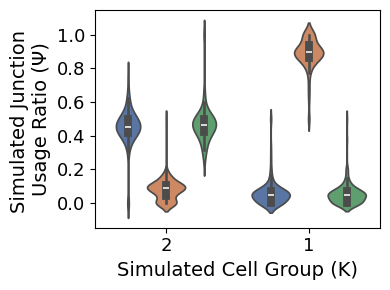

In [22]:
unique_clusters = adata_input.var.Cluster.unique()

clust = np.random.choice(unique_clusters, size=1, replace=False).item() 

simple_data_junc = adata_input.var[adata_input.var.Cluster == clust]
junc_indices = simple_data_junc["junction_id_index"].values

# Get cell specific junction usage ratios 
junc_data = adata_input[:, junc_indices].layers["junc_ratio"]

junc_data_dense = junc_data.toarray() if hasattr(junc_data, 'toarray') else junc_data
junc_df = pd.DataFrame(junc_data_dense, index = adata_input.obs.index, columns=simple_data_junc["junction_id_index"].values)
junc_df["cell_id_index"] = junc_df.index 

junc_df = junc_df.melt(id_vars="cell_id_index" , var_name="junction_id_index", value_name="junc_ratio")

junc_df = junc_df.dropna(subset=["junc_ratio"])
junc_df = junc_df.merge(simple_data_junc[["junction_id_index", "junction_id", "sample_label",	"difference",	"true_label"]])

if adata_input.obs["cell_id_index"].dtype != junc_df['cell_id_index'].dtype:
    adata_input.obs["cell_id_index"] = adata_input.obs["cell_id_index"].astype(junc_df['cell_id_index'].dtype)

junc_df = junc_df.merge(adata_input.obs[["cell_id_index", "cell_type"]])

print(junc_df[["junction_id_index", "junction_id", "difference", "true_label"]].drop_duplicates())
print(junc_df.cell_type.value_counts())
# Update cell_type where cell_type is 0 to "1"
junc_df.loc[junc_df["cell_type"] == 0, "cell_type_clean"] = "2"

# Update cell_type where cell_type is 1 to "2"
junc_df.loc[junc_df["cell_type"] == 1, "cell_type_clean"] = "1"

plt.figure(figsize=(4, 3))  # This will create a narrower plot

# Plotting
sns.set_palette("deep")  # You can also try "husl", "pastel", "deep", etc.
sns.violinplot(data=junc_df, y="junc_ratio", x="cell_type_clean", hue="junction_id_index", palette="deep")

# Increase font size for x and y labels
plt.ylabel('Simulated Junction \nUsage Ratio (Ψ)', fontsize=14)
plt.xlabel('Simulated Cell Group (K)', fontsize=14)

# Move the legend outside the plot and increase font size
plt.legend().remove()

# Increase the font size for the tick labels
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# Adjust layout to prevent clipping of the legend
plt.tight_layout()

# save as PDF 
plt.savefig('positive_simulation_violin_plot.pdf', format='pdf')
plt.show()

plt.close()